(surface-protein-annotation)=
# Annotation

(surface-protein-annotation-key-takeaway-1)=
## Motivation

Similar to scRNA-seq data, it is possible to annotate the ADT data based on surface protein markers. 
This can be very beneficial for the annotation of immune cells, since they are difficult to annotate in the RNA space and they are well described by their surface proteins. 
scRNA-seq data can suffer from dropouts, that is, although a gene is expressed in a cell population, the gene is not detected in some cells due to limitations of the sequencing procedure. 
Instead, ADT data does not suffer so much from dropouts due to using antibodies to quantify surface proteins. 
Therefore individual surface proteins show a stronger signal in the ADT data than in the RNA data.

For example, although sequenced immune cells usually include CD45 cells, the CD45 gene is not always highly expressed in the RNA data. 
This can be mitigated by annotating (additionally) on the ADT level.

The general annotation workflow makes use of the same functions as for RNA data and no ADT-specific functions are required.

## Environment setup

In [ ]:
import warnings

import muon as mu
import scanpy as sc

warnings.filterwarnings("ignore")
mu.set_options(pull_on_update=False)
sc.settings.verbosity = 0
sc.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

import lamindb as ln

ln.track()

→ loaded Transform('BnpvfJLWjHuE0005', key='annotation.ipynb'), re-started Run('QEKKxvVQBGXwIHKf') at 2026-04-10 17:37:56 UTC
→ notebook imports: lamindb-core==2.3.1 muon==0.1.7 scanpy==1.12
• recommendation: to identify the notebook across renames, pass the uid: ln.track("BnpvfJLWjHuE")


## Loading the data

We load the MuData object we saved at the end of the previous chapter {ref}`surface-protein-batch-correction`:

In [3]:
af = ln.Artifact.connect("theislab/sc-best-practices").get(
    key="surface-protein/cite_batch_correction.h5mu", is_latest=True
)
mdata = af.load()
mdata

MuData object with n_obs × n_vars = 117951 × 36737
  var:	'gene_ids', 'feature_types'
  2 modalities
    rna:	117951 x 36601
      obs:	'donor', 'batch'
      var:	'gene_ids', 'feature_types'
    prot:	117951 x 136
      obs:	'donor', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'outliers', 'doublets_markers'
      var:	'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      uns:	'batch_colors', 'donor_colors', 'doublets_markers_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'

## Manual annotation

First, we check the expression of CD45. 
CD45 is one of the most abundant proteins in the T-cell plasma membrane and required for TCR signaling. 
It activates Lck, which in turn is required to phosphorylate the TCR complex {cite}`sp:Courtney2019`. 
Therefore, CD45 should be broadly expressed in our dataset, and even more highly expressed in T cells.

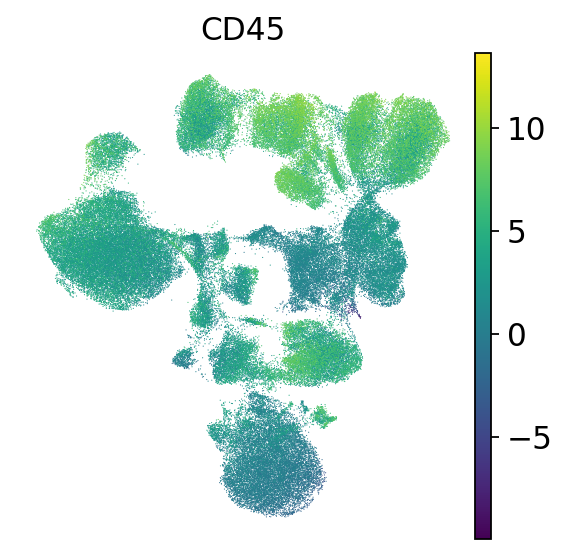

In [4]:
sc.pl.umap(mdata["prot"], frameon=False, color="CD45")

The measured ADTs use a slightly different nomenclature due to name clashes with RNA genes. 
The `var_names_make_unique` function was used to separate gene names from protein names and the proteins might have `-1` suffixes.
We look up an example gene name (CD38) to exemplarily find the exact nomenclature in our variable names:

In [5]:
mdata["prot"].var[mdata["prot"].var.gene_ids.str.contains("CD38")]

,gene_ids,feature_types,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
CD38-1,CD38,Antibody Capture,116434,52.892694,3.986995,4.57481,6453755.0,15.680173


We cluster the cells with a relatively low resolution. 
Similarly to scRNA-seq data annotation, it is possible to increase the resolution for more fine-grained annotations.

In [ ]:
sc.tl.leiden(
    mdata["prot"],
    resolution=0.1,
    flavor="igraph",
    n_iterations=2,
    directed=False,
    random_state=0,
)

To check which surface markers are present in which cell type, we use the scanpy rank_genes_groups() function and then we create a dotplot. 
The dotplot will indicate the 3 most differentially expressed genes in each cluster.

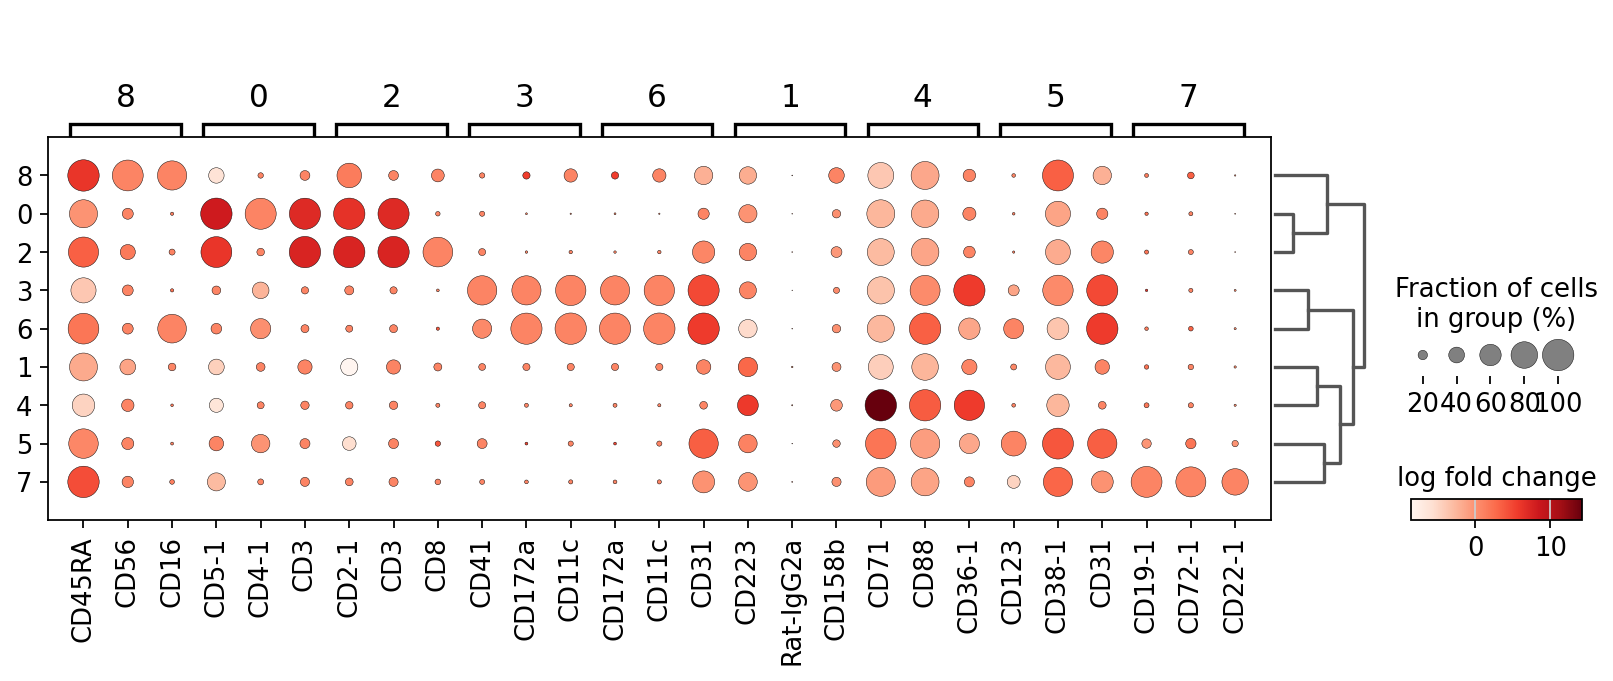

In [7]:
sc.tl.rank_genes_groups(mdata["prot"], groupby="leiden")
sc.tl.dendrogram(mdata["prot"], groupby="leiden")
sc.pl.rank_genes_groups_dotplot(
    mdata["prot"], n_genes=3, values_to_plot="logfoldchanges"
)

We can already identify clusters 0 and 2 as T cell populations by CD3 expression, and cluster 7 as B cells by CD19 expression.
We next plot the UMAP that we calculated in our previous chapters and color it by cluster.

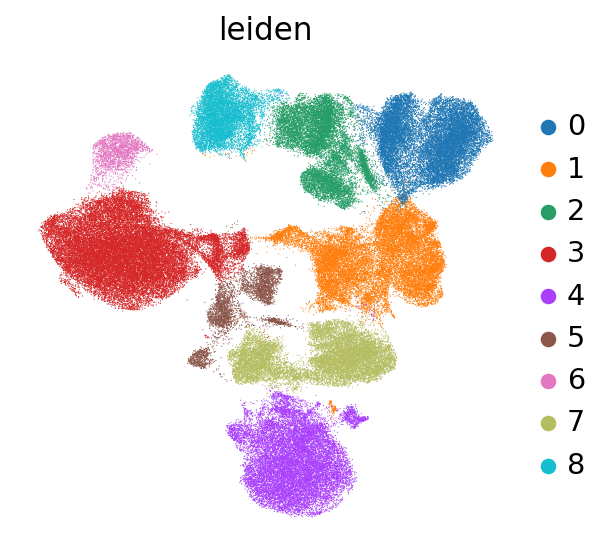

In [8]:
sc.pl.umap(mdata["prot"], color="leiden")

We'll check a few known markers of major immune cell types in order to identify which cell type is each cluster.

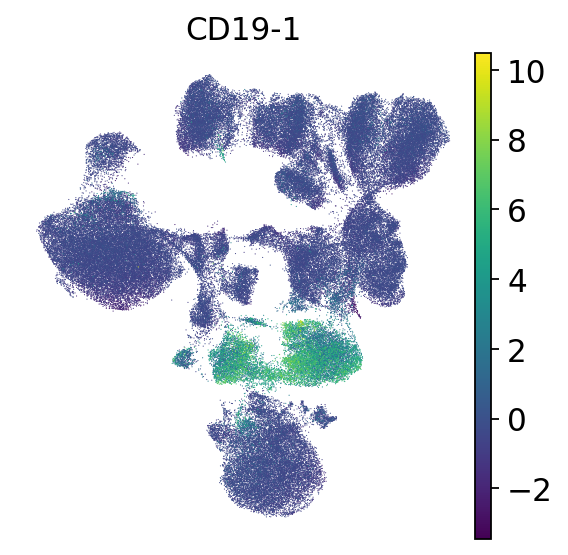

In [9]:
# B cells
sc.pl.umap(mdata["prot"], frameon=False, color=["CD19-1"])

As could be seen in the dotplot, cluster 7 expresses CD19 which is a B cell marker.

Let's look into the T cells in more detail and separate them into CD4 and CD8 cells.

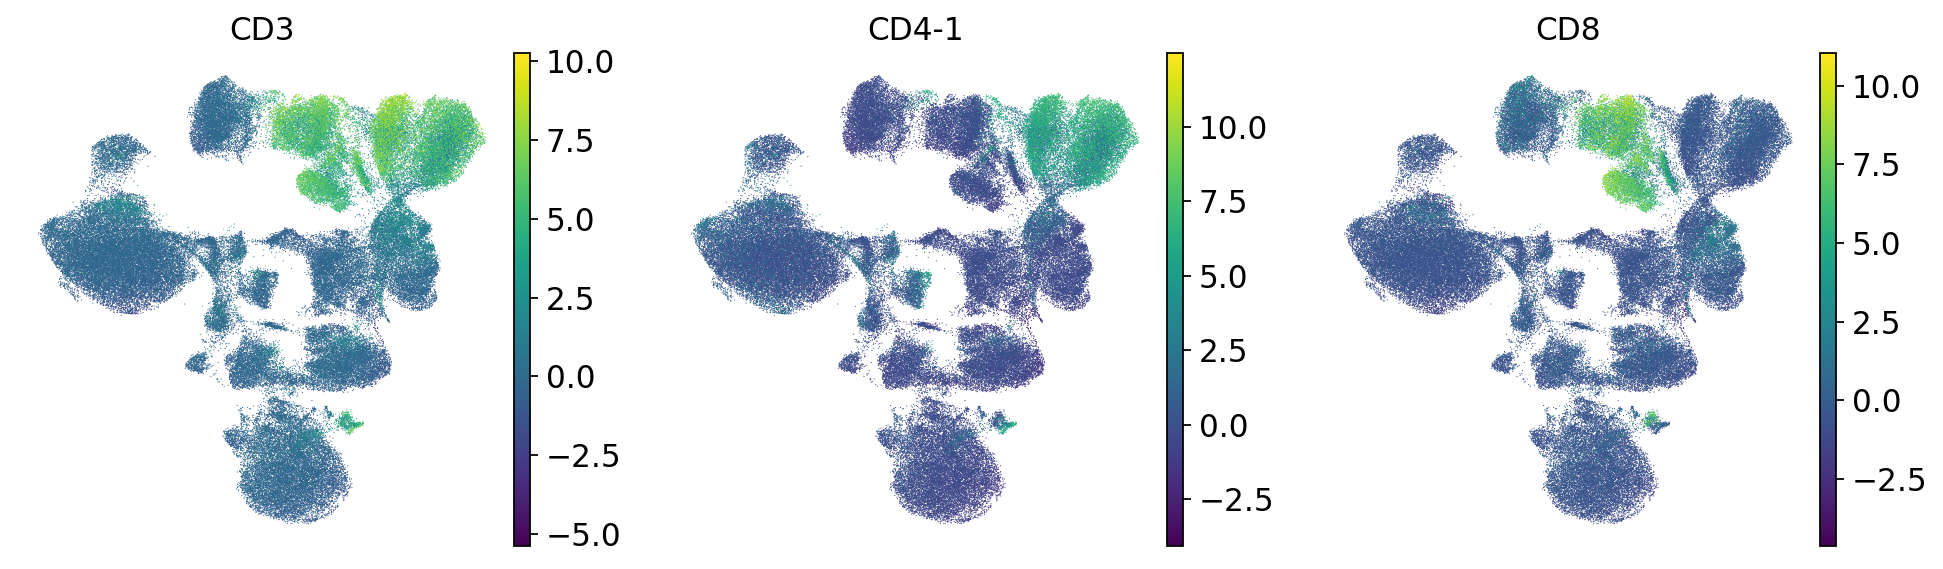

In [10]:
# T cells
sc.pl.umap(mdata["prot"], color=["CD3", "CD4-1", "CD8"])

In the following few plots, we continue looking for known markers of other cell types: NK cells, monocytes and dendritic cells.

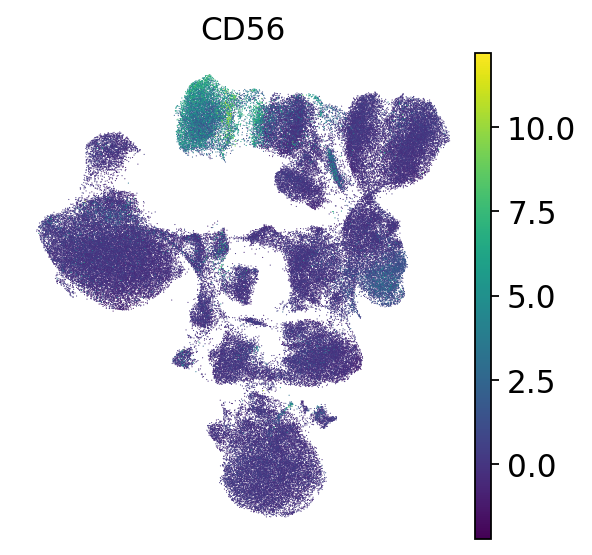

In [11]:
# NKT cells are CD3+ and CD56+
# NK cells are CD3- and CD56+
sc.pl.umap(mdata["prot"], color=["CD56"], frameon=False)

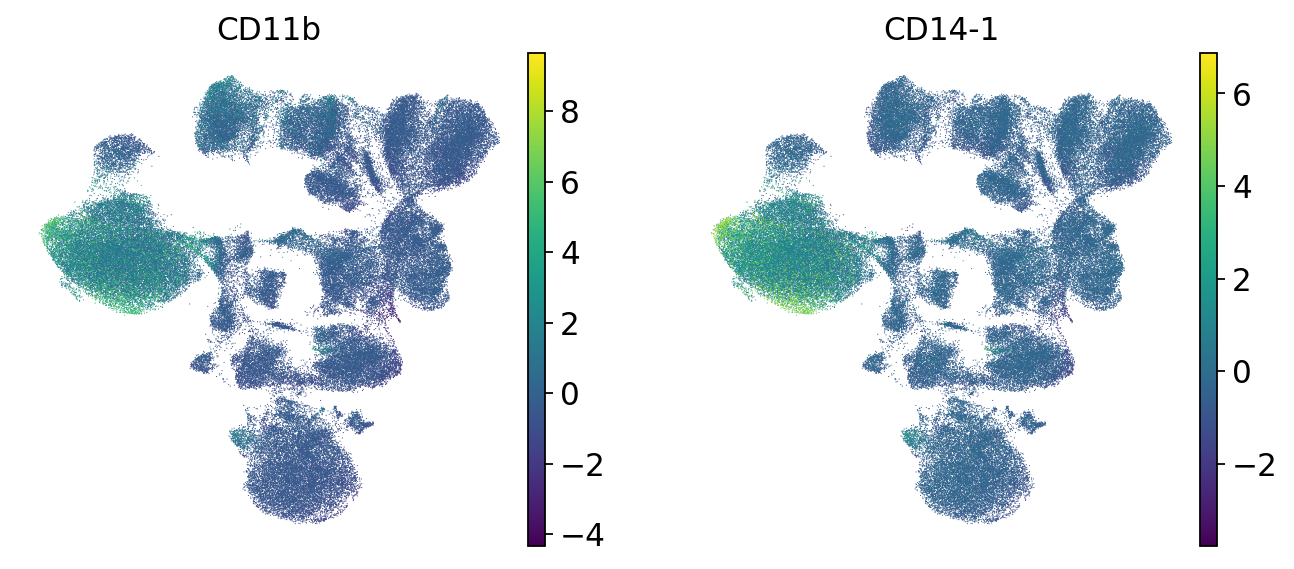

In [12]:
# Monocytes
sc.pl.umap(mdata["prot"], color=["CD11b", "CD14-1"], frameon=False)

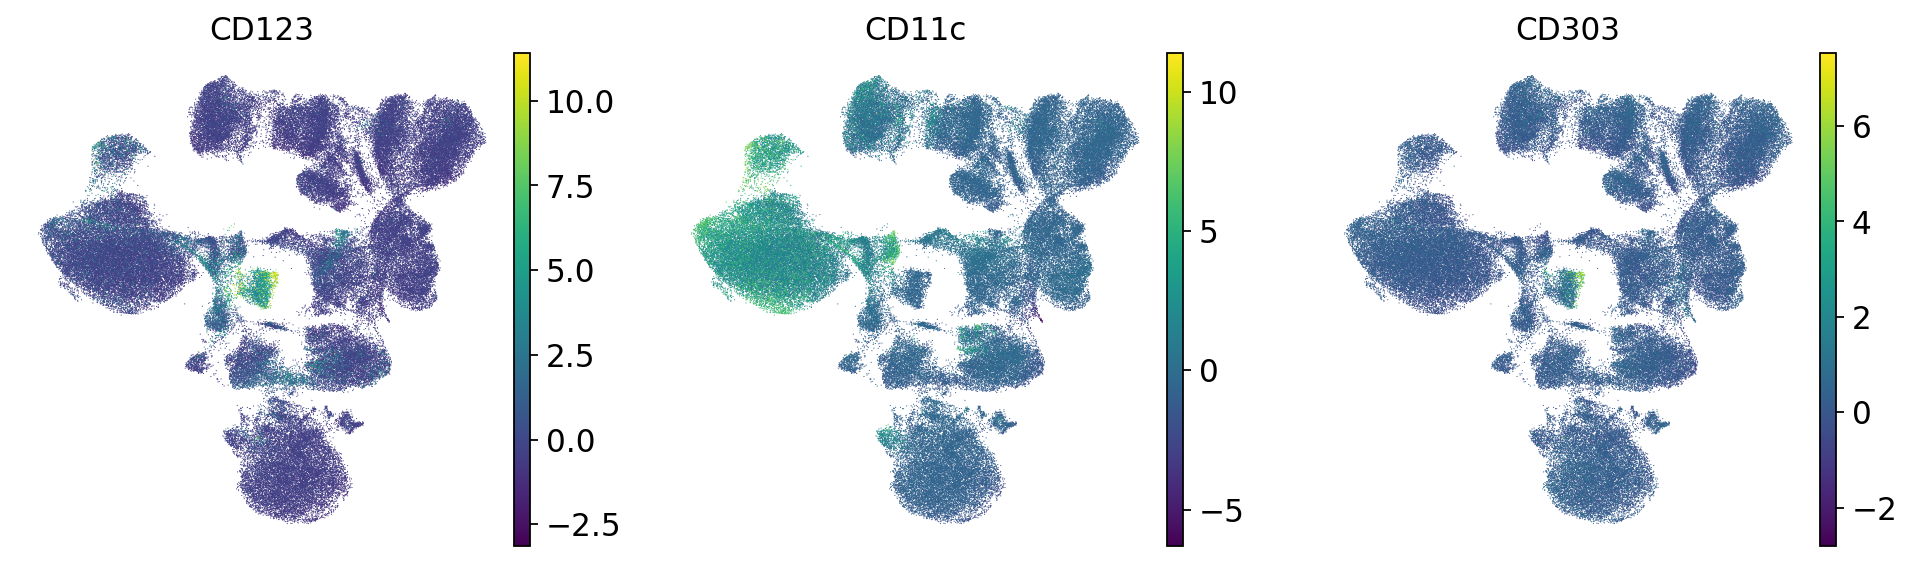

In [13]:
# Dendritic
sc.pl.umap(mdata["prot"], color=["CD123", "CD11c", "CD303"], frameon=False)

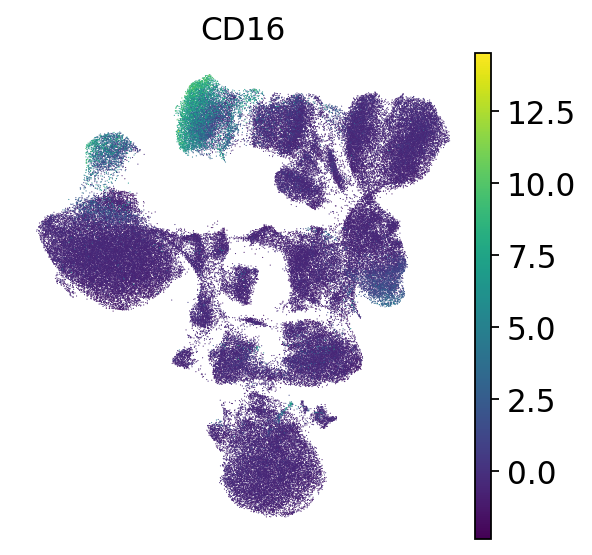

In [14]:
# CD16 is expressed in NK cells and in CD16 monocytes, which are CD14-, CD16+ and CD11c+
sc.pl.umap(mdata["prot"], color="CD16", frameon=False)

Now that we know what cell type each cluster is, let's replace the 0-8 cluster numbers with the actual cell type names:

In [15]:
mdata["prot"].obs["celltype"] = mdata["prot"].obs.leiden.copy()
mdata["prot"].obs.celltype.replace(
    {
        "0": "CD4 T",
        "1": "Cytotoxic T",
        "2": "CD8 T",
        "3": "CD14 Mono",
        "4": "Proliferating cells",
        "5": "DC",
        "6": "CD16 Mono",
        "7": "B",
        "8": "NK",
    },
    inplace=True,
)

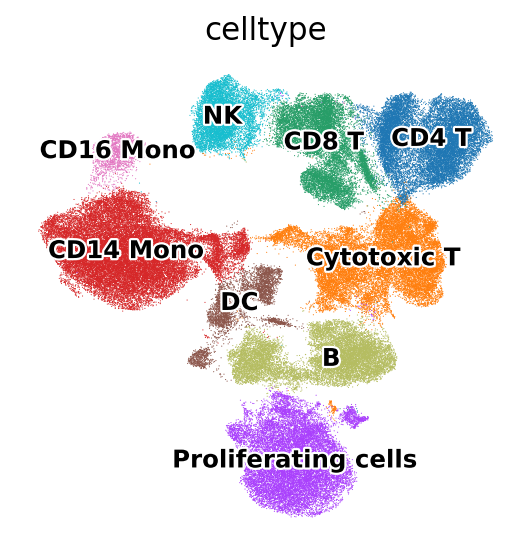

In [16]:
sc.pl.umap(
    mdata["prot"],
    color="celltype",
    legend_loc="on data",
    legend_fontsize=11,
    legend_fontoutline=2,
)

We have uncovered and annotated the main cell types in the data. 
Now we could perform a more fine-grained annotation by increasing the resolution of clustering and annotating the resulting fine-grained clusters.

In this chapter we describe how to annotate cell types based on the ADT data of CITE-seq. 
Another interesting way forward is to annotate cell types based on combined information from ADT and from RNA data. 
We refer to the {ref}`multimodal-integration-paired-integration` chapter for that.

In [17]:
af_annotation = ln.Artifact.from_mudata(
    mdata,
    key="surface-protein/cite_annotation.h5mu",
    description="CITE-seq data after annotation",
)
af_annotation.save()

→ creating new artifact version for key 'surface-protein/cite_annotation.h5mu' in storage 's3://lamin-eu-central-1/VPwcjx3CDAa2'
... uploading OyfKOZw9TXUQXeOp0002.h5mu: 100.0%
• replacing the existing cache path /var/cache/user/marchena/.cache/lamindb/lamin-eu-central-1/VPwcjx3CDAa2/surface-protein/cite_annotation.h5mu


Artifact(uid='OyfKOZw9TXUQXeOp0002', key='surface-protein/cite_annotation.h5mu', description='CITE-seq data after annotation', suffix='.h5mu', kind='dataset', otype='MuData', size=1547653954, hash='4ak2wDSMz6ov6E1UoXSPa8', n_files=None, n_observations=117951, branch_id=1, created_on_id=1, space_id=1, storage_id=1, run_id=76, schema_id=None, created_by_id=7, created_at=2026-04-10 17:38:14 UTC, is_locked=False, version_tag=None, is_latest=True)

In [18]:
ln.finish()

• please hit CTRL + s to save the notebook in your editor ... ✓
! cells [(0, 2)] were not run consecutively
! returning transform  with same hash & key: Transform(uid='BnpvfJLWjHuE0004', key='annotation.ipynb', description='Annotation', kind='notebook', hash='wGPLIESjWMSUD0apYkREXQ', reference=None, reference_type=None, environment=None, plan=None, branch_id=1, created_on_id=1, space_id=1, created_by_id=7, created_at=2026-04-10 17:10:35 UTC, is_locked=False, version_tag=None, is_latest=False)
• new latest Transform version is: BnpvfJLWjHuE0004
→ finished Run('QEKKxvVQBGXwIHKf') after 48s at 2026-04-10 17:38:44 UTC
→ go to: https://lamin.ai/theislab/sc-best-practices/transform/BnpvfJLWjHuE0004
→ to update your notebook from the CLI, run: lamin save /groups/nils/members/javier/single-cell-best-practices/jupyter-book/surface_protein/annotation.ipynb


## Automated annotation

It is technically possible to use cell type classifiers trained on ADT data and to map against ADT reference datasets. 
However, ADT-specific methods are sparse if not non-existent, and we refer to the RNA annotation chapter for methodological details {ref}`cellular-structure-annotation`.

## References

```{bibliography}
:filter: docname in docnames
```

## Contributors

We gratefully acknowledge the contributions of:

### Authors

* Javier Marchena-Hurtado
* Daniel Strobl
* Ciro Ramírez-Suástegui

### Reviewers

* Lukas Heumos
* Anna Schaar